In [6]:
import mne

In [3]:
raw = mne.io.read_raw_edf('edfs/shhs1-200001.edf')

Extracting EDF parameters from /Users/mithunarun/Documents/GitHub/saurons_eye/edfs/shhs1-200001.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


Using matplotlib as 2D backend.


/var/folders/vw/vxs6h2gs6_j6t149_mctz78m0000gp/T/ipykernel_66961/1229894758.py:1: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  raw.plot()


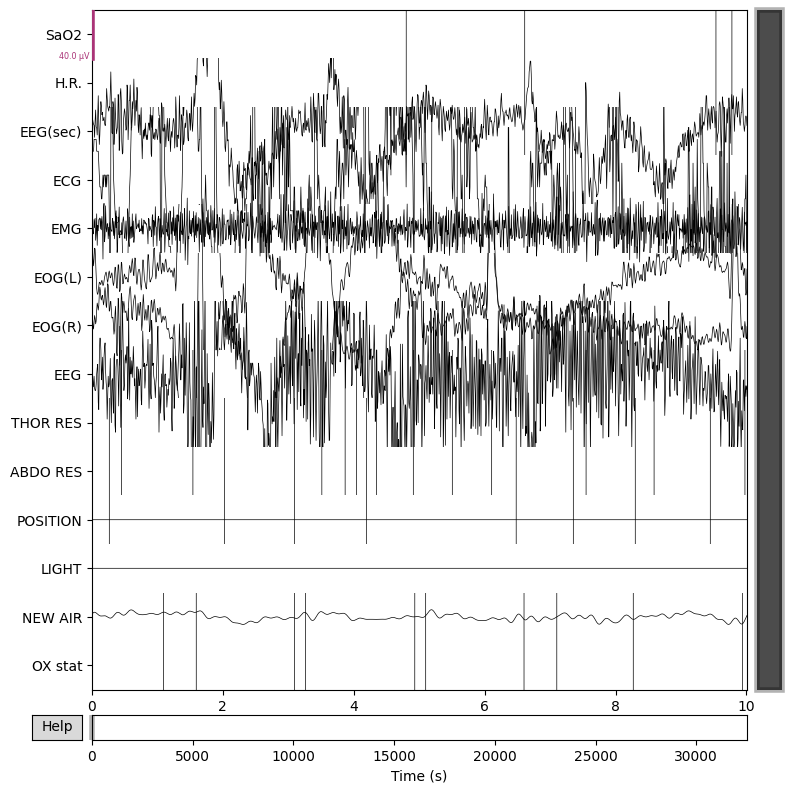

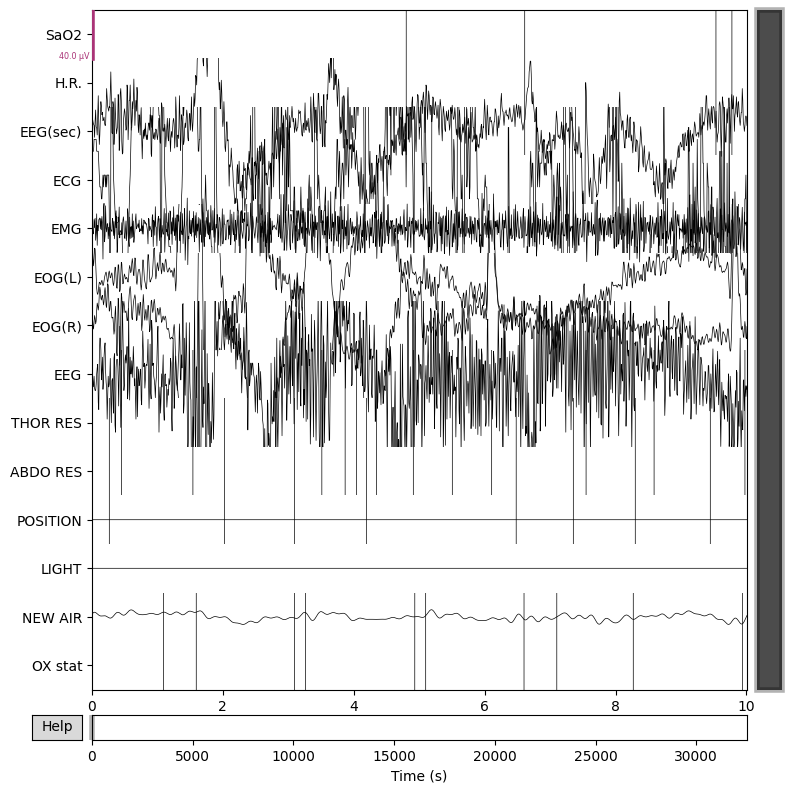

In [4]:
raw.plot()

In [9]:
spectrum = raw.compute_psd(method='welch', fmin=0.5, fmax=30)
psds = spectrum.get_data(picks='eeg') # Or specify your desired channel type
freqs = spectrum.freqs

Effective window size : 16.384 (s)


In [10]:
print(freqs)

[ 0.54931641  0.61035156  0.67138672  0.73242188  0.79345703  0.85449219
  0.91552734  0.9765625   1.03759766  1.09863281  1.15966797  1.22070312
  1.28173828  1.34277344  1.40380859  1.46484375  1.52587891  1.58691406
  1.64794922  1.70898438  1.77001953  1.83105469  1.89208984  1.953125
  2.01416016  2.07519531  2.13623047  2.19726562  2.25830078  2.31933594
  2.38037109  2.44140625  2.50244141  2.56347656  2.62451172  2.68554688
  2.74658203  2.80761719  2.86865234  2.9296875   2.99072266  3.05175781
  3.11279297  3.17382812  3.23486328  3.29589844  3.35693359  3.41796875
  3.47900391  3.54003906  3.60107422  3.66210938  3.72314453  3.78417969
  3.84521484  3.90625     3.96728516  4.02832031  4.08935547  4.15039062
  4.21142578  4.27246094  4.33349609  4.39453125  4.45556641  4.51660156
  4.57763672  4.63867188  4.69970703  4.76074219  4.82177734  4.8828125
  4.94384766  5.00488281  5.06591797  5.12695312  5.18798828  5.24902344
  5.31005859  5.37109375  5.43212891  5.49316406  5.55

Processing: shhs1-200001 (Age=55.0)


/var/folders/vw/vxs6h2gs6_j6t149_mctz78m0000gp/T/ipykernel_66961/1635189680.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  delta_ch = np.trapz(data, freqs, axis=1)  # integrate over frequency → V^2


  DeltaPower=0.0693858 V^2
Processing: shhs1-200002 (Age=78.0)
  DeltaPower=0.129366 V^2
Processing: shhs1-200003 (Age=77.0)
  DeltaPower=0.0544679 V^2
Processing: shhs1-200004 (Age=48.0)
  DeltaPower=0.0510969 V^2
Processing: shhs1-200005 (Age=66.0)
  DeltaPower=0.0201796 V^2
Processing: shhs1-200006 (Age=63.0)
  DeltaPower=0.0188013 V^2
Processing: shhs1-200007 (Age=52.0)
  DeltaPower=0.0597975 V^2
Processing: shhs1-200008 (Age=63.0)
  DeltaPower=0.0530631 V^2
Processing: shhs1-200009 (Age=69.0)
  DeltaPower=0.0564932 V^2
Processing: shhs1-200010 (Age=40.0)
  DeltaPower=0.0567473 V^2


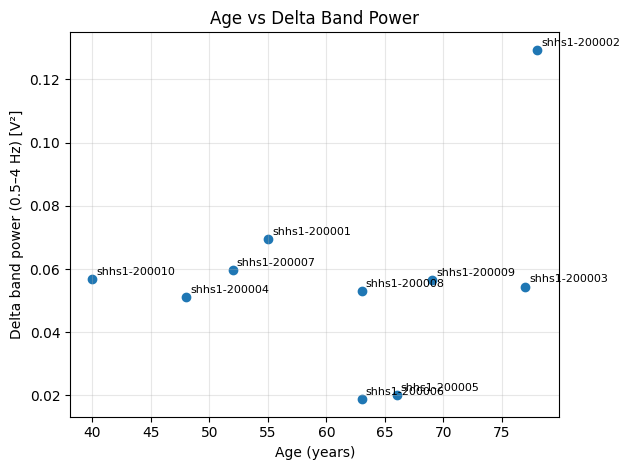

In [15]:
# edf_delta_power_from_csv.py
# Usage: python edf_delta_power_from_csv.py
# Requires: mne, numpy, pandas, matplotlib

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

EDF_FOLDER = "./edfs"
CSV_PATH = "./shhs-cvd-summary-dataset-0.16.0.csv"  # same dir as this script (adjust if needed)

FMIN, FMAX = 0.5, 4.0      # delta band (Hz)
RESAMPLE_HZ = 100          # set to None to keep native rate
ANNOTATE_POINTS = True     # label points with short filenames on the plot

def compute_delta_power(raw):
    """Absolute delta-band power (0.5–4 Hz) averaged across EEG channels, via Welch PSD."""
    picks = mne.pick_types(raw.info, eeg=True, meg=False, eog=False, ecg=False)
    if len(picks) == 0:
        raise RuntimeError("No EEG channels found.")

    raw = raw.copy().pick(picks)

    # standardize a bit and remove drift
    if RESAMPLE_HZ is not None and abs(raw.info["sfreq"] - RESAMPLE_HZ) > 1e-6:
        raw.resample(RESAMPLE_HZ, npad="auto")
    raw.filter(l_freq=0.3, h_freq=None, picks="eeg", verbose="ERROR")

    sf = raw.info["sfreq"]
    n_per_seg = int(4.0 * sf)       # 4-second Welch window
    n_overlap = int(0.5 * n_per_seg)

    psd = raw.compute_psd(
        method="welch",
        fmin=FMIN, fmax=FMAX,
        n_fft=n_per_seg,
        n_per_seg=n_per_seg,
        n_overlap=n_overlap,
        average="mean",
        proj=True,
        verbose="ERROR"
    )
    freqs = psd.freqs
    data = psd.get_data()           # (n_channels, n_freqs), V^2/Hz
    delta_ch = np.trapz(data, freqs, axis=1)  # integrate over frequency → V^2
    return float(np.nanmean(delta_ch))        # mean across EEG channels

def main():
    # 1) EDF files (sorted)
    edf_files = sorted(
        os.path.join(EDF_FOLDER, f)
        for f in os.listdir(EDF_FOLDER)
        if f.lower().endswith(".edf")
    )
    if not edf_files:
        print(f"No .edf files found in {EDF_FOLDER}")
        return

    # 2) Ages from CSV: use rows 2–11 (inclusive) → iloc[1:11], column "age_s1"
    try:
        df = pd.read_csv(CSV_PATH)
    except FileNotFoundError:
        print(f"CSV not found at: {CSV_PATH}")
        return

    if "age_s1" not in df.columns:
        print('CSV is missing required column "age_s1".')
        return

    ages_series = df["age_s1"].iloc[0:10]  # rows 2–11 in human terms
    ages_list = ages_series.astype(float).tolist()

    # 3) Align by position: row 2 ↔ first EDF (after sorting), etc.
    n_pairs = min(len(edf_files), len(ages_list))
    if n_pairs == 0:
        print("No overlapping EDF/age pairs to process.")
        return

    edf_files = edf_files[:n_pairs]
    ages_list = ages_list[:n_pairs]

    ages = []
    powers = []
    labels = []

    for path, age in zip(edf_files, ages_list):
        short = os.path.splitext(os.path.basename(path))[0]
        print(f"Processing: {short} (Age={age})")
        try:
            raw = mne.io.read_raw_edf(path, preload=True, verbose="ERROR")
            dpow = compute_delta_power(raw)
            ages.append(float(age))
            powers.append(dpow)
            labels.append(short[:24])  # short label
            print(f"  DeltaPower={dpow:.6g} V^2")
        except Exception as e:
            print(f"  Skipped due to error: {e}")

    if len(ages) == 0:
        print("No successful EDF/age pairs. Nothing to plot.")
        return

    # 4) Scatter plot
    plt.figure()
    plt.scatter(ages, powers)
    if ANNOTATE_POINTS:
        for x, y, lab in zip(ages, powers, labels):
            plt.annotate(lab, (x, y), xytext=(3, 3), textcoords="offset points", fontsize=8)
    plt.xlabel("Age (years)")
    plt.ylabel("Delta band power (0.5–4 Hz) [V²]")
    plt.title("Age vs Delta Band Power")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()
